In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
import os
# Definición de ruta
file_path =  '../../data/raw/fridge_fault_timeseries_dataset.csv' #https://www.kaggle.com/datasets/samoilovmikhail/simulated-refrigerator-fault-diagnosis-dataset?resource=download
#other for ULT refrigerators: https://lab.compute.dtu.dk/taohu/ult-freezers-labelled-dataset-sci-data/-/tree/main/data/dataset?ref_type=heads
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Dataset cargado exitosamente. Formato: {df.shape}")
else:
    print("Error: El archivo no existe en la ruta especificada.")
    
print(df.head())
#df.isna().sum()
df.describe()

Dataset cargado exitosamente. Formato: (1872000, 21)
       T_amb     T_set      T_cab  T_evap_sat  T_cond_sat  P_suc_bar  \
0  22.187599  2.627537  22.111991   18.162151   30.019587   4.964200   
1  22.372591  2.627537  21.962171   18.119603   30.427325   4.905156   
2  22.328321  2.627537  21.838008   17.999535   30.270884   4.875609   
3  22.614706  2.627537  21.775435   18.109126   30.685874   4.895076   
4  22.428984  2.627537  21.661756   17.692930   30.322264   4.876375   

   P_dis_bar  N_comp_Hz      SH_K  P_comp_W  ...  COP  frost_level  \
0   7.322867       87.0  6.476948     600.0  ...  5.0     0.084003   
1   7.531698       87.0  6.021818     600.0  ...  5.0     0.083803   
2   7.408313       87.0  5.971117     600.0  ...  5.0     0.083603   
3   7.418943       87.0  6.002439     600.0  ...  5.0     0.083403   
4   7.507421       87.0  6.119263     600.0  ...  5.0     0.083203   

   T_cab_meas  valve_open  time_min  run_id   fault fault_id  door_open  \
0   22.251928    0

,T_amb,T_set,T_cab,T_evap_sat,T_cond_sat,P_suc_bar,P_dis_bar,N_comp_Hz,SH_K,P_comp_W,Q_evap_W,COP,frost_level,T_cab_meas,valve_open,time_min,run_id,fault_id,door_open,defrost_on
count,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06,1.872000e+06
mean,2.502810e+01,3.220848e+00,2.131217e+01,1.613717e+01,3.326359e+01,4.957957e+00,8.185168e+00,7.650492e+01,7.297271e+00,5.178258e+02,3.888621e+02,4.641907e+00,6.018202e-02,2.131302e+01,4.610819e-01,7.195000e+02,6.495000e+02,6.000000e+00,4.831944e-02,3.399145e-02
std,5.234617e+00,1.021385e+00,7.061757e+00,1.327970e+01,5.649930e+00,1.461210e+00,1.505371e+00,1.805654e+01,1.958237e+00,1.591568e+02,3.855537e+02,1.108437e+00,2.377869e-01,7.077854e+00,5.874712e-02,4.156922e+02,3.752777e+02,3.741658e+00,2.144404e-01,1.812072e-01
min,1.093664e+01,1.506844e+00,-1.686483e+00,-4.536191e+01,1.618393e+01,4.695570e-01,4.493195e+00,0.000000e+00,4.522527e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.667282e+00,2.293190e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.126294e+01,2.298816e+00,1.762674e+01,1.400686e+01,2.922573e+01,4.329147e+00,7.067831e+00,7.483404e+01,5.942414e+00,4.555741e+02,0.000000e+00,5.000000e+00,0.000000e+00,1.762915e+01,4.244928e-01,3.597500e+02,3.247500e+02,3.000000e+00,0.000000e+00,0.000000e+00
50%,2.499133e+01,3.215166e+00,2.081207e+01,1.738082e+01,3.320422e+01,4.828974e+00,8.035276e+00,8.279456e+01,6.282454e+00,5.371618e+02,3.562177e+02,5.000000e+00,0.000000e+00,2.074392e+01,4.915264e-01,7.195000e+02,6.495000e+02,6.000000e+00,0.000000e+00,0.000000e+00
75%,2.878534e+01,4.104362e+00,2.555930e+01,2.259967e+01,3.725473e+01,5.711263e+00,9.157249e+00,8.700000e+01,8.516908e+00,5.916144e+02,6.081197e+02,5.000000e+00,0.000000e+00,2.562239e+01,5.017276e-01,1.079250e+03,9.742500e+02,9.000000e+00,0.000000e+00,0.000000e+00
max,3.924128e+01,4.998877e+00,4.332525e+01,4.283289e+01,5.141683e+01,1.097812e+01,1.450918e+01,8.700000e+01,1.502270e+01,1.743657e+03,2.656341e+03,5.000000e+00,1.200000e+00,4.332275e+01,5.443242e-01,1.439000e+03,1.299000e+03,1.200000e+01,1.000000e+00,1.000000e+00


In [27]:
# Some new features based on domain knowledge

def extract_physics_features(df):
    # Diferenciales térmicos
    df['T_error'] = df['T_cab'] - df['T_set']
    df['T_lift'] = df['T_cond_sat'] - df['T_evap_sat']
    # Si el condensador está sucio, la temperatura de saturación (T_cond_sat) se aleja mucho de la ambiente
    df['T_cond_approach'] = df['T_cond_sat'] - df['T_amb'] 
    df['T_spread'] = df['T_cond_sat'] - df['T_evap_sat']
    df['T_cab_meas_diff'] = df['T_cab'] - df['T_cab_meas'] 

    # Presiones y potencia
    df['P_ratio'] = df['P_dis_bar'] / (df['P_suc_bar'] + 0.1)
    df['Power_per_diff'] = df['P_comp_W'] / (df['T_lift'] + 0.1)

    # Eficiencia de transferencia: Vatios consumidos por cada grado de enfriamiento
    df['Q_est'] = df['P_comp_W'] / (df['T_cab'] - df['T_evap_sat'] + 1e-5)

    # Error de sensor 
    df['Sensor_error'] = df['T_cab'] - df['T_cab_meas'] 
    
    # Derivadas (Tendencias instantáneas)
    df['T_cab_grad'] = df.groupby('run_id')['T_cab'].diff().fillna(0)
    df['P_suc_rate'] = df.groupby('run_id')['P_suc_bar'].diff().fillna(0)

    df['Eff_vol'] = (df['T_evap_sat'] + 273.15) / (df['T_cond_sat'] + 273.15)
    df['P_suc_norm'] = df['P_suc_bar'] / df['T_amb']

    # Desviación de saturación (Crucial para detectar Aire/Incondensables - Clase 11)
    df['P_dis_error'] = df['P_dis_bar'] - (df['T_cond_sat'] * 0.25)

    # Diferencial de Subenfriamiento aproximado
    df['T_subcooling_approx'] = df['T_cond_sat'] - df['T_amb'] 
    # Relación Potencia-Presión
    df['Power_to_Pratio'] = df['P_comp_W'] / (df['P_ratio'] + 0.1)

    # Estabilidad de presión
    df['P_dis_volatility'] = df.groupby('run_id')['P_dis_bar'].transform(lambda x: x.rolling(window=5).std()).fillna(0)

    df["pressure_ratio"] = df["P_dis_bar"] / (df["P_suc_bar"] + 0.1)
    df["specific_work"] = df["P_comp_W"] / (df["Q_evap_W"]+ 0.1)
    df["cop_degradation"] = df["COP"] / df.groupby("run_id")["COP"].transform("max")

    # --- NUEVAS VARIABLES CRÍTICAS (PREDICTIVE) ---
    # Índice de eficiencia energética: relación entre el esfuerzo eléctrico y la capacidad de absorber calor
    df['EEI'] = df['P_comp_W'] / (df['T_cab'] - df['T_evap_sat'] + 0.1)
    # Carga térmica relativa (basada en inercia de producto si aplica)
    df['Thermal_Load_Index'] = (df['T_cab'] - df['T_evap_sat']) * df['P_ratio']

    return df

# Aplicar extracción
df = extract_physics_features(df)
df = df.sort_values(["run_id", "time_min"])

def create_lag_features(df, features, lags):
    for feature in features:
        for lag in lags:
            df[f"{feature}_lag_{lag}"] = (
                df.groupby("run_id")[feature]
                  .shift(lag)
            )
            df[f"{feature}_delta_{lag}"] = (
                df[feature] - df[f"{feature}_lag_{lag}"]
            )
    return df

# Ampliamos lag_features con variables de diagnóstico experto
lag_features = ["P_dis_bar", "T_cond_sat"]
# Lags: 5 (inestabilidad), 15 (tendencia media), 45 (deriva térmica lenta de suciedad)
lags = [5, 15, 45]

df = create_lag_features(df, lag_features, lags)

# Mantenemos tu lag largo pero ajustado a una ventana más realista para el predictivo
df['P_dis_error_lag_100'] = df.groupby("run_id")["P_dis_error"].shift(100)

def create_rolling_features(df, features, windows):
    for feature in features:
        for w in windows:
            roll = (
                df.groupby("run_id")[feature]
                  .rolling(w, min_periods=w//2)
            )
            df[f"{feature}_roll_std_{w}"] = df.groupby("run_id")[feature].transform(lambda x: x.rolling(w, min_periods=w//2).std())
            df[f"{feature}_roll_mean_{w}"] = roll.mean().reset_index(level=0, drop=True)
    return df

rolling_features = ["P_dis_bar", "T_cond_sat", "EEI"]
windows = [15, 30]

df = create_rolling_features(df, rolling_features, windows)

# Estabilidad refinada de presión
df["P_dis_bar_roll_std_20"] = (
    df.groupby("run_id")["P_dis_bar"]
      .rolling(20, min_periods=10)
      .std()
      .reset_index(level=0, drop=True)
)

df["P_dis_bar_roll_mean_20"] = (
    df.groupby("run_id")["P_dis_bar"]
      .rolling(20, min_periods=10)
      .mean()
      .reset_index(level=0, drop=True)
)

df["Pdis_instability_20"] = df["P_dis_bar_roll_std_20"] / (df["P_dis_bar_roll_mean_20"] + 1e-5)

# Inestabilidad en la transferencia térmica (Condensador)
df["cond_approach_std_20"] = (
    df.groupby("run_id")["T_cond_approach"]
      .rolling(20, min_periods=10)
      .std()
      .reset_index(level=0, drop=True)
)

# Limpieza final de NaNs generados por los nuevos lags
df = df.dropna(subset=[
    "Pdis_instability_20",
    "P_dis_bar_delta_15"
])

In [28]:
def physics_indicators(df):
    phys = pd.DataFrame(index=df.index)
    
    # 1. Spikes de presión inicial (Clave para detectar Aire/Incondensables vs Suciedad)
    # Calculamos la media de los primeros 100 puntos de cada ciclo
    phys['early_P_dis_error'] = df.groupby('run_id')['P_dis_error'].transform(lambda x: x.iloc[:100].mean())
    phys['mean_P_dis_bar'] = df.groupby('run_id')['P_dis_bar'].transform('mean')
    
    # 2. Indicadores de diagnóstico para las reglas LTN
    phys['T_cab_meas_diff'] = df['T_cab'] - df['T_cab_meas'] # Para Sensor Drift
    phys['Eff_vol'] = (df['T_evap_sat'] + 273.15) / (df['T_cond_sat'] + 273.15) # Eficiencia
    phys['T_cond_approach'] = df['T_cond_sat'] - df['T_amb'] # Para Fouling
    
    return phys

# Ejecutar la extracción de indicadores físicos
physics_feats = physics_indicators(df)

# Unir al DataFrame principal evitando duplicados
cols_to_add = physics_feats.columns.difference(df.columns)
df_phys = df.join(physics_feats[cols_to_add])

print(f"Columnas físicas añadidas para LTN: {list(cols_to_add)}")

Columnas físicas añadidas para LTN: ['early_P_dis_error', 'mean_P_dis_bar']


In [29]:

from sklearn.model_selection import train_test_split

#Mapping
target_mapping = {
    "NORMAL": 0, "COND_FOUL_MILD": 1, "COND_FOUL_SEVERE": 2,
    "EVAP_FAN_DEG": 3, "EVAP_FAN_FAIL": 4, "UNDERCHARGE_MILD": 5,
    "UNDERCHARGE_SEVERE": 6, "OVERCHARGE": 7, "SENSOR_DRIFT_PLUS": 8,
    "SENSOR_DRIFT_MINUS": 9, "COMP_INEFFICIENCY": 10, "NON_CONDENSABLES": 11,
    "UNDERCHARGE_AND_COND_FOUL": 12
}


df_phys['fault_numeric'] = df_phys['fault'].map(target_mapping)

#STRATIFIED SPLIT BY RUN
run_labels = df_phys.groupby('run_id')['fault_numeric'].first()
unique_runs = run_labels.index

train_runs, test_runs = train_test_split(
    unique_runs, 
    test_size=0.2, 
    random_state=42,
    stratify=run_labels 
)

train_df = df_phys[df_phys['run_id'].isin(train_runs)].copy()
test_df  = df_phys[df_phys['run_id'].isin(test_runs)].copy()


target_column = 'fault_numeric'
drop_cols = [target_column, 'fault', 'run_id', 'fault_id']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target_column]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target_column]

print("Mapped fault labels:", target_mapping)
print(f"Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}")

#SAMPLE WEIGHTS (TRAIN ONLY)
#sample_weights = compute_sample_weights(train_df)

#Scaling
binary_cols = ['defrost_on', 'door_open']
numerical_cols = [c for c in X_train.columns if c not in binary_cols]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit only on Training data to avoid data leakage
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

X_train_scaled = X_train_scaled.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_scaled = X_test_scaled.replace([np.inf, -np.inf], np.nan).fillna(0)

# Asegurar que no hay NaNs en las etiquetas
y_train = y_train.fillna(0)

print(f"Total features: {X_train_scaled.shape[1]}")

Mapped fault labels: {'NORMAL': 0, 'COND_FOUL_MILD': 1, 'COND_FOUL_SEVERE': 2, 'EVAP_FAN_DEG': 3, 'EVAP_FAN_FAIL': 4, 'UNDERCHARGE_MILD': 5, 'UNDERCHARGE_SEVERE': 6, 'OVERCHARGE': 7, 'SENSOR_DRIFT_PLUS': 8, 'SENSOR_DRIFT_MINUS': 9, 'COMP_INEFFICIENCY': 10, 'NON_CONDENSABLES': 11, 'UNDERCHARGE_AND_COND_FOUL': 12}
Training samples: 1482000 | Testing samples: 370500
Total features: 71


In [30]:
import ltn
import tensorflow as tf

# Habilitar compatibilidad de tipos
tf.experimental.numpy.experimental_enable_numpy_behavior()

# Definimos los operadores con la sintaxis exacta para tu versión
p_mean = ltn.fuzzy_ops.Aggreg_pMean(p=2)
# Nota: semantics debe ser un string según el core.py de tu instalación
forall_op = ltn.Wrapper_Quantifier(aggreg_op=p_mean, semantics="forall")
not_op = ltn.Wrapper_Connective(ltn.fuzzy_ops.Not_Std())
and_aggregator = ltn.Wrapper_Formula_Aggregator(ltn.fuzzy_ops.Aggreg_pMean(p=2))

print("Motor LTN configurado.")

Motor LTN configurado.


In [31]:
num_classes = len(target_mapping)

model_keras = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

print(f"Modelo Neuro-Simbólico listo para {num_classes} clases.")

Modelo Neuro-Simbólico listo para 13 clases.


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
def knowledge_base(features_tensor, labels_numeric):
    preds = model_keras(features_tensor)
    preds = tf.clip_by_value(preds, 1e-7, 1.0 - 1e-7) 
    rules = []
    cols = list(X_train_scaled.columns)
    
    # REGLA: SENSOR DRIFT
    if 'T_cab_meas_diff' in cols:
        idx_diff = cols.index('T_cab_meas_diff')
        mask_drift = tf.abs(features_tensor[:, idx_diff]) > 2.0
        
        # SEGURIDAD: Solo añadir la regla si hay datos que la activan
        if tf.reduce_any(mask_drift):
            prob_normal = tf.boolean_mask(preds[:, 0], mask_drift)
            # Evitar tensores de tamaño 0
            if tf.shape(prob_normal)[0] > 0:
                v_drift = ltn.Variable("v_drift", prob_normal)
                rules.append(forall_op([v_drift], not_op(ltn.core.Formula(v_drift.tensor, ["v_drift"]))))

    # REGLA: NC vs CF
    if 'P_dis_error' in cols:
        idx_p_error = cols.index('P_dis_error')
        mask_nc_spike = features_tensor[:, idx_p_error] > 1.5
        
        if tf.reduce_any(mask_nc_spike):
            prob_foul = tf.boolean_mask(preds[:, 2], mask_nc_spike)
            if tf.shape(prob_foul)[0] > 0:
                v_nc = ltn.Variable("v_nc", prob_foul)
                rules.append(forall_op([v_nc], not_op(ltn.core.Formula(v_nc.tensor, ["v_nc"]))))

    # Si no hay reglas activas en este batch, devolvemos satisfacción total (1.0)
    if not rules:
        return ltn.core.Formula(tf.constant(0.999), []) # Evitamos el 1.0 puro por estabilidad
        
    return and_aggregator(rules)

In [33]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005) # Un poco más lento para mayor estabilidad
cce = tf.keras.losses.SparseCategoricalCrossentropy()

x_tensor = tf.constant(X_train_scaled.values, dtype=tf.float32)
y_tensor = tf.constant(y_train.values, dtype=tf.int32)

print("Iniciando entrenamiento Híbrido (CCE + LTN)...")
for epoch in range(401):
    with tf.GradientTape() as tape:
        # 1. Predicción y pérdida de datos pura (CCE)
        preds = model_keras(x_tensor, training=True)
        loss_data = cce(y_tensor, preds)
        
        # 2. Satisfacción lógica (Knowledge Base)
        sat_level = knowledge_base(x_tensor, y_tensor)
        loss_logic = 1.0 - sat_level.tensor
        
        # 3. Combinación balanceada
        # Si ves que no respeta las reglas, sube el peso de loss_logic a 0.5
        total_loss = (0.7 * loss_data) + (0.3 * loss_logic)
        
    if tf.math.is_nan(total_loss):
        print(f"NaN detectado en epoch {epoch}. Revisa los escalados.")
        break
        
    gradients = tape.gradient(total_loss, model_keras.trainable_variables)
    
    # --- GRADIENT CLIPPING ---
    # Evita que el modelo "explote" si la lógica choca con los datos
    gradients = [tf.clip_by_value(g, -1.0, 1.0) if g is not None else g for g in gradients]
    
    optimizer.apply_gradients(zip(gradients, model_keras.trainable_variables))
    
    if epoch % 20 == 0:
        # Calculamos precisión simple para ver progreso en tiempo real
        correct_preds = tf.equal(tf.argmax(preds, axis=1, output_type=tf.int32), y_tensor)
        acc = tf.reduce_mean(tf.cast(correct_preds, tf.float32))
        print(f"Epoch {epoch:3d} | Sat: {sat_level.tensor.numpy():.4f} | Acc: {acc.numpy():.4f} | Loss: {total_loss.numpy():.4f}")

Iniciando entrenamiento Híbrido (CCE + LTN)...
Epoch   0 | Sat: 0.9476 | Acc: 0.0660 | Loss: 1.8930
Epoch  20 | Sat: 0.9490 | Acc: 0.3674 | Loss: 1.4793
Epoch  40 | Sat: 0.9582 | Acc: 0.4805 | Loss: 1.1711
Epoch  60 | Sat: 0.9660 | Acc: 0.5861 | Loss: 0.8736
Epoch  80 | Sat: 0.9706 | Acc: 0.6977 | Loss: 0.6523
Epoch 100 | Sat: 0.9749 | Acc: 0.7601 | Loss: 0.4995
Epoch 120 | Sat: 0.9775 | Acc: 0.8013 | Loss: 0.3976
Epoch 140 | Sat: 0.9791 | Acc: 0.8336 | Loss: 0.3282
Epoch 160 | Sat: 0.9801 | Acc: 0.8574 | Loss: 0.2766
Epoch 180 | Sat: 0.9808 | Acc: 0.8761 | Loss: 0.2356
Epoch 200 | Sat: 0.9811 | Acc: 0.8896 | Loss: 0.2031
Epoch 220 | Sat: 0.9815 | Acc: 0.8995 | Loss: 0.1782
Epoch 240 | Sat: 0.9816 | Acc: 0.9062 | Loss: 0.1603
Epoch 260 | Sat: 0.9817 | Acc: 0.9111 | Loss: 0.1471
Epoch 280 | Sat: 0.9817 | Acc: 0.9146 | Loss: 0.1373
Epoch 300 | Sat: 0.9818 | Acc: 0.9174 | Loss: 0.1299
Epoch 320 | Sat: 0.9818 | Acc: 0.9194 | Loss: 0.1242
Epoch 340 | Sat: 0.9819 | Acc: 0.9211 | Loss: 0.1196

In [34]:
inverse_target_mapping = {v: k for k, v in target_mapping.items()}
def ltn_post_reasoning(X_phys_df, neural_model, X_scaled_values, mapping):
    # 1. Obtener predicciones de la red neuronal
    y_pred_probs = neural_model.predict(X_scaled_values)
    y_pred_final = np.argmax(y_pred_probs, axis=1)
    
    ids = {name: mapping[name] for name in mapping}

    # --- REGLAS DE SEGURIDAD (HARD CONSTRAINTS) ---
    # Si después del entrenamiento algo sale del rango lógico, lo forzamos aquí
    
    # Regla: Sensor Drift (Si el error es masivo, el modelo debe marcarlo)
    y_pred_final[X_phys_df['T_cab_meas_diff'] > 2.5]  = ids["SENSOR_DRIFT_MINUS"]
    y_pred_final[X_phys_df['T_cab_meas_diff'] < -2.5] = ids["SENSOR_DRIFT_PLUS"]

    # Regla: Ineficiencia Crítica
    y_pred_final[(X_phys_df['Eff_vol'] < 0.45)] = ids["COMP_INEFFICIENCY"]

    return y_pred_final

# Ejecución usando los valores escalados del set de test
y_pred_ns = ltn_post_reasoning(test_df, model_keras, X_test_scaled.values, target_mapping)

print(f"Predicciones listas. NC detectados: {(y_pred_ns == 11).sum()}")

11579/11579 ━━━━━━━━━━━━━━━━━━━━ 4s 374us/step
Predicciones listas. NC detectados: 25619


In [37]:
from sklearn.metrics import classification_report

def apply_run_voting(df, y_pred):
    df_temp = df.copy()
    df_temp['y_pred'] = y_pred
    
    # Encontramos la predicción más frecuente para cada ciclo (run_id)
    run_votes = df_temp.groupby('run_id')['y_pred'].transform(
        lambda x: x.value_counts().idxmax()
    )
    return run_votes.values

# 1. Usamos el resultado de la celda anterior (y_pred_ns) 
# que ya tiene incorporadas las reglas de seguridad final.
y_pred_final_voted = apply_run_voting(test_df, y_pred_ns)

# --- REPORTES ---
# Asegúrate de que inverse_target_mapping esté definido
selected_ids = [0, 2, 11] # Normal, Suciedad Severa, No condensables


--- CLASSIFICATION REPORT FINAL: NEURO-SYMBÓLICO + VOTO ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28500
           1       1.00      1.00      1.00     28500
           2       0.43      0.50      0.47     28500
           3       1.00      1.00      1.00     28500
           4       1.00      1.00      1.00     28500
           5       1.00      1.00      1.00     28500
           6       1.00      1.00      1.00     28500
           7       1.00      1.00      1.00     28500
           8       1.00      1.00      1.00     28500
           9       1.00      1.00      1.00     28500
          10       1.00      1.00      1.00     28500
          11       0.41      0.35      0.38     28500
          12       1.00      1.00      1.00     28500

    accuracy                           0.91    370500
   macro avg       0.91      0.91      0.91    370500
weighted avg       0.91      0.91      0.91    370500



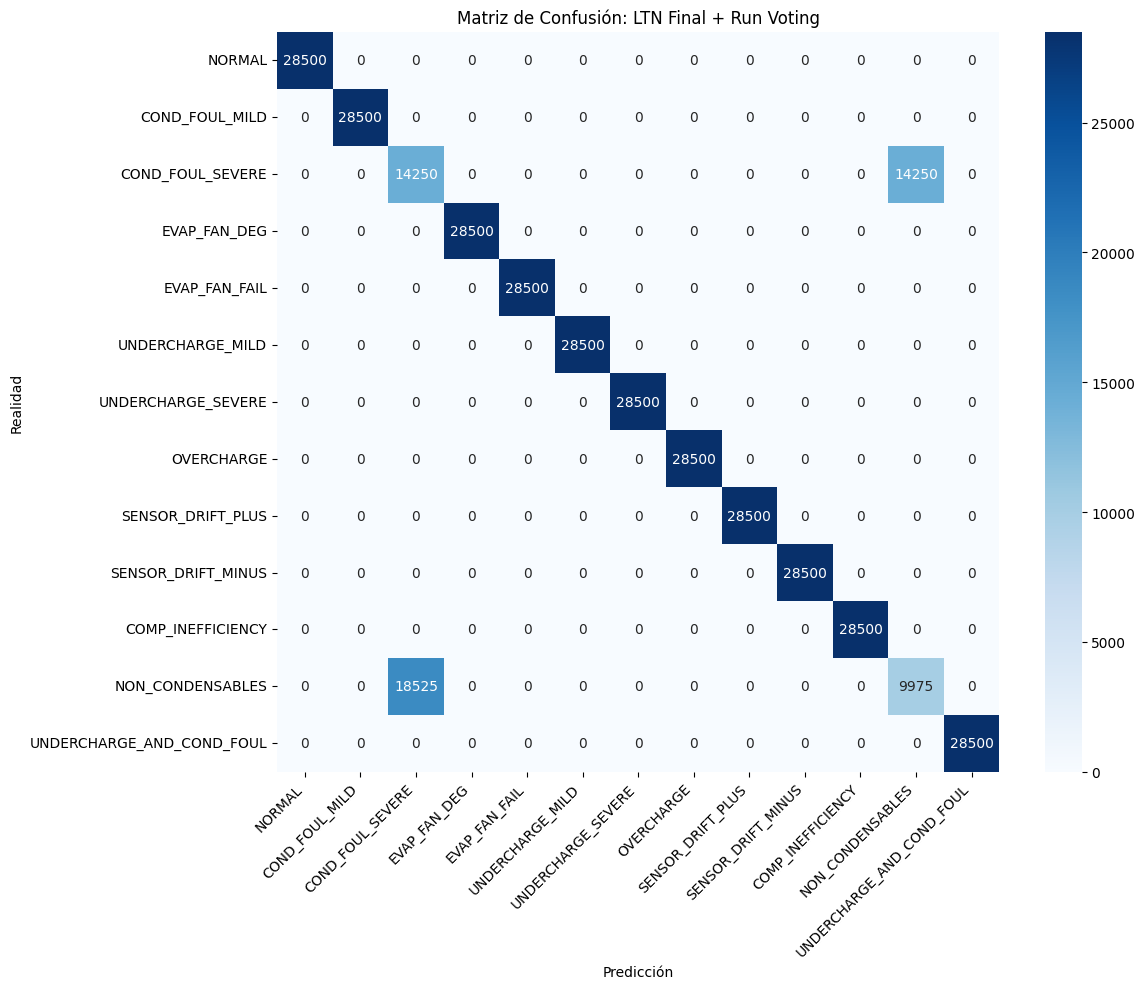

In [38]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_clean_confusion_matrix(y_true, y_pred, title, cmap):
    # Obtenemos las etiquetas en el orden correcto (0, 1, 2...)
    labels = sorted(target_mapping.values())
    names = [inverse_target_mapping[i] for i in labels]
    
    plt.figure(figsize=(12, 10))
    # Pasamos labels=labels para asegurar que la matriz no ignore clases vacías
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, 
                xticklabels=names, yticklabels=names)
    
    plt.title(title)
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 1. Usamos la predicción que ya pasó por el filtro de seguridad (y_pred_ns)
# 2. Aplicamos el voto por run_id para la máxima estabilidad
y_pred_final_voted = apply_run_voting(test_df, y_pred_ns)

print('--- CLASSIFICATION REPORT FINAL: NEURO-SYMBÓLICO + VOTO ---')
print(classification_report(y_test, y_pred_final_voted))

# Dibujamos la matriz
plot_clean_confusion_matrix(y_test, y_pred_final_voted, 'Matriz de Confusión: LTN Final + Run Voting', 'Blues')